In [1]:
# Modeler:  build a set of landscape_stacks, sample, then build
#   models around those

In [2]:
# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Landsat_OLI",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.02,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.03,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.01,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 3,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.10,
                },
            },
        },

        {
            "name": "Sentinel2_MSI",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 8.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 2.0,
                "beta": 5.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.3,
            },
        },
    },
}

In [3]:
# Configuration dictionary: 
experiment_config = {
    "n_stacks": 10,
    "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",   # <- directory with many .tif
    "patch_selection_seed": 123,         # optional, for reproducible choice

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 50,
    "sampling_seed": 42,
}

In [4]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection



collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=experiment_config,
)

samples = collection.stratified_sample(
    sensor_name=experiment_config["sensor_name_for_strat"],
    n_strata=experiment_config["n_strata"],
    samples_per_stratum=experiment_config["samples_per_stratum"],
    sampling_seed=experiment_config["sampling_seed"],
    include_truth=True,
)


samples.head()

,stack_id,stack_index,sensor_name,row,col,stratum,sensor_value,interpreter_prob,cover_loss,final_cover,disturbed
0,DL_0a28987e,0,Landsat_OLI,78,282,0,4.023766,20.973754,0.0000,85.7000,False
1,DL_0a28987e,0,Landsat_OLI,101,32,0,52.687323,23.621346,6.5700,83.4300,False
2,DL_0a28987e,0,Landsat_OLI,88,278,0,19.993991,19.533197,2.5194,94.3806,False
3,DL_0a28987e,0,Landsat_OLI,17,305,0,-54.145816,22.530975,0.2460,81.7540,False
4,DL_0a28987e,0,Landsat_OLI,154,132,0,38.660084,25.979658,4.5288,84.2712,False


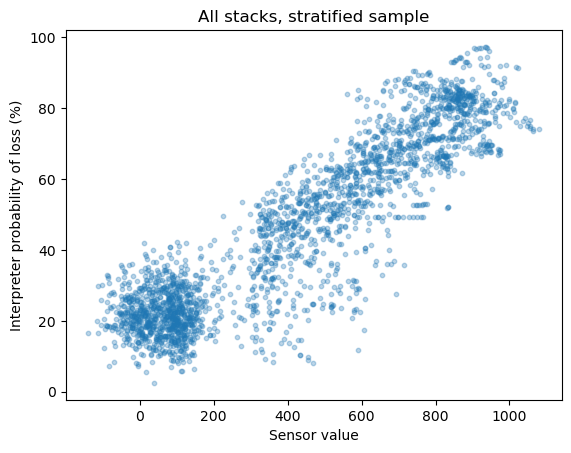

In [5]:
import matplotlib.pyplot as plt

plt.scatter(samples["sensor_value"], samples["interpreter_prob"], alpha=0.3, s=10)
plt.xlabel("Sensor value")
plt.ylabel("Interpreter probability of loss (%)")
plt.title("All stacks, stratified sample")
plt.show()


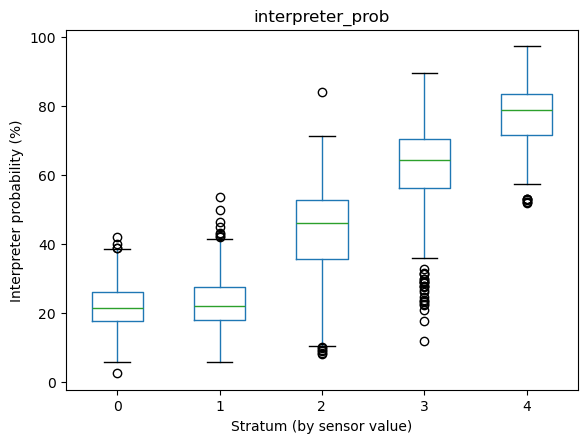

In [6]:
samples.boxplot(column="interpreter_prob", by="stratum", grid=False)
plt.suptitle("")
plt.xlabel("Stratum (by sensor value)")
plt.ylabel("Interpreter probability (%)")
plt.show()


In [7]:
# testing building a model from this. 
#  


from landscape_stack_collection import LandscapeStackCollection

# 1. Build collection
collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=experiment_config,
)

# 2. Fit models for all sensors
collection.buildModel(
    sensor_names=None,         # None → all sensors found in first stack
    n_strata=5,
    samples_per_stratum=200,
    sampling_seed=123,
)

# Inspect model parameters
collection.models

{'Landsat_OLI': {'sensor_name': 'Landsat_OLI',
  'params': {'a': -1.4807806777410806, 'b': 0.0029879217766206156},
  'fit_covariance': [[7.618882976726293e-05, -1.2131357983094353e-07],
   [-1.2131357983094353e-07, 2.6609696186145447e-10]],
  'n_samples': 9915,
  'strata': {'n_strata': 5, 'samples_per_stratum': 200},
  'experiment_config': {'n_stacks': 10,
   'disturbance_seed_base': 10000,
   'use_separate_seeds_per_stack': True,
   'patch_dir': 'downloaded_images/',
   'patch_selection_seed': 123,
   'sensor_name_for_strat': 'Landsat_OLI',
   'n_strata': 5,
   'samples_per_stratum': 50,
   'sampling_seed': 42},
  'base_config_example': {'random': {'seed': 10000},
   'raster': {'band': 1},
   'types': {'type1': {'name': 'Conifer',
     'proportion_of_patches': 0.6,
     'initial_cover': {'target_mean': 0.9, 'kappa': 20.0},
     'proportional_loss': {'mixture': {'catastrophic_probability': 0.02,
       'background_alpha': 0.3,
       'background_beta': 8.0,
       'catastrophic_alpha':

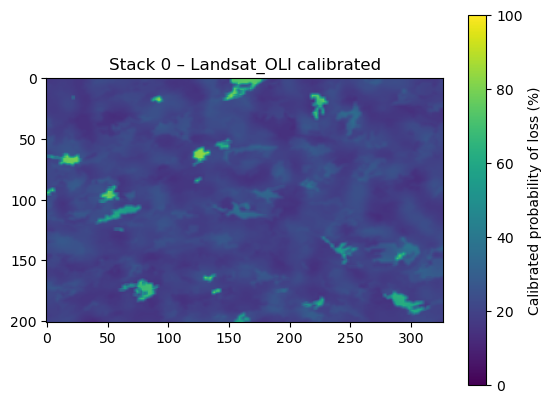

In [8]:
# 3. Apply models to all stacks
collection.applyModel()

# 4. Look at one calibrated surface
stack0 = collection.stacks[5]
cal_oli = stack0.calibrated_prob_by_sensor["Landsat_OLI"]

plt.imshow(cal_oli, vmin=0, vmax=100, cmap="viridis")
plt.colorbar(label="Calibrated probability of loss (%)")
plt.title("Stack 0 – Landsat_OLI calibrated")
plt.show()

In [9]:
#writing out the model. 

# import json

# with open("models.json", "w") as f:
#     json.dump(collection.models, f, indent=2)

# # Later / different session:
# with open("models.json", "r") as f:
#     loaded_models = json.load(f)

# collection.loadModel(loaded_models)
# collection.applyModel()

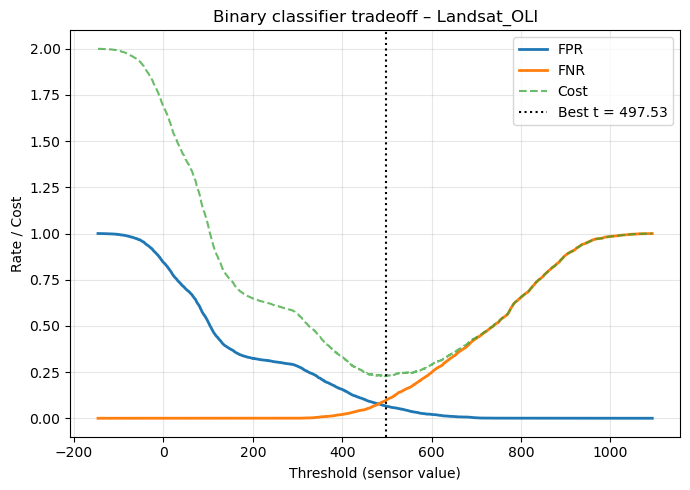

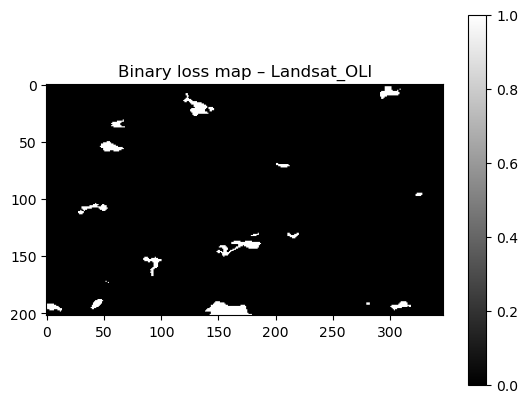

In [10]:
####   Build the binary classifier using more traditional approaches


# Build classifiers for all sensors
collection.buildBinaryClassifier(
    sensor_names=None,           # None → all sensors
    n_strata=5,
    samples_per_stratum=200,
    sampling_seed=123,
    fp_to_fn_ratio=2.0,          # e.g., FPs are twice as costly as FNs
)

# Visualize tradeoff curves
collection.plotBinaryCurves("Landsat_OLI")

# Apply the classifier to all stacks
collection.applyBinaryClassifier()

# Look at a binary loss map for one stack/sensor
stack0 = collection.stacks[0]
bin_map = stack0.binary_class_by_sensor["Landsat_OLI"]

import matplotlib.pyplot as plt
plt.imshow(bin_map, cmap="gray")
plt.title("Binary loss map – Landsat_OLI")
plt.colorbar()
plt.show()

In [ ]:
# import json
# # REading and writing binary classifiers

# # Write it out
# with open("binary_models.json", "w") as f:
#     json.dump(collection.binary_models, f, indent=2)

# # Read it in
# with open("binary_models.json", "r") as f:
#     binary_models = json.load(f)

# collection.loadBinaryModel(binary_models)

# # Apply them to produce binary maps
# collection.applyBinaryClassifier()
